# Kinetic Monte-Carlo

In this exercise we will program a KMC code that simulates a surface growth process. The processes that can occur during surface growth are adsorption, desorption and diffusion. The rates for these processes can depend on different factors.

First we program a simple example that does not use a lattice and assumes rates to be constant values.
Then we will use the same rates, but on a lattice. Finally we will make the rates dependent on the number of neighbors and see how this changes the result. 

The basic steps in the KMC simulation are the following:
- Build the event list
- Randomly draw an event from the list according to its rate
- Execute the event
- Advance time according to the rate (and Poisson distribution)
- Repeat

In [1]:
from ase import build, visualize, data
from asap3 import FullNeighborList
import numpy as np
from matplotlib import pyplot as plt

### 2D, coverage without lattice, constant rates

In [2]:
rnd = np.random.default_rng(42)

# --- Parameters ---
NSITES = 10000   # Total available sites
Nocc   = 0.       # Number of occupied sites at t=0
Nemp   = NSITES   # Number of empty sites at t=0
rD     = 4.       # Desorption rate constant
rA     = 1.       # Adsorption rate constant
STEPS  = 10       # Number of MC steps per site

# --- Initialization ---
theta  = Nocc / NSITES
t      = 0
THETA  = [theta]
TIME   = [t]

# --- KMC Loop ---
print(f"Simulating {STEPS*NSITES} events...")

for step in range(STEPS * NSITES):
    # 1. Calculate total rates based on current state
    # Rate of desorption = constant * number of occupied sites
    RD = rD * Nocc
    # Rate of adsorption = constant * number of empty sites
    RA = rA * Nemp
    
    # Total activity
    R_total  = RD + RA
    
    # 2. Calculate Probabilities
    # Probability that the next event is Desorption
    pD = RD / R_total
    # Probability that the next event is Adsorption
    pA = RA / R_total
    
    # 3. Select Event
    r = rnd.uniform(0, 1)
    
    if r < pD:
        # Desorption Event Occurs
        Nocc -= 1
        Nemp += 1
    else:
        # Adsorption Event Occurs
        Nocc += 1
        Nemp -= 1

    # 4. Advance Time
    # Time steps in KMC are Poisson-distributed
    u = rnd.uniform(0, 1)
    dt = -np.log(u) / R_total
    t += dt

    # Store data for plotting
    theta = Nocc / NSITES
    THETA.append(theta)
    TIME.append(t)

print("Simulation finished.")

Simulating 100000 events...
Simulation finished.


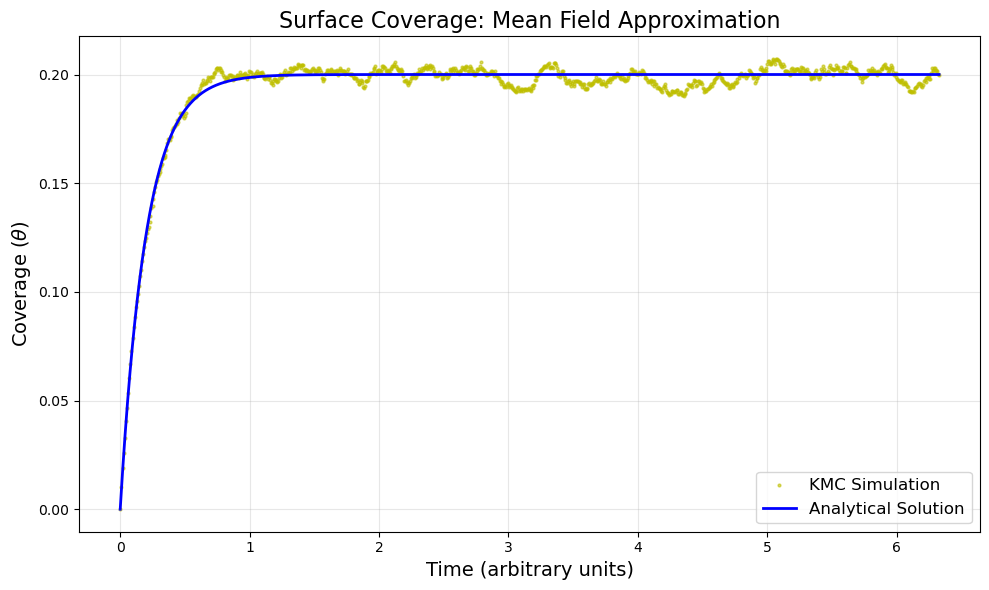

In [3]:
# Convert lists to numpy arrays for calculation
TIME = np.array(TIME)
THETA = np.array(THETA)

# Analytical Solution for comparison
# steady state coverage = rA / (rA + rD)
THETA_ANA = rA / (rA + rD) * (1 - np.exp(-(rA + rD) * TIME))

plt.figure(figsize=(10, 6))
# Plot only a subset of points to keep the plot clean
plt.plot(TIME[::100], THETA[::100], "yo", label="KMC Simulation", markersize=2, alpha=0.6)
plt.plot(TIME, THETA_ANA, "b-", lw=2, label="Analytical Solution")

plt.title("Surface Coverage: Mean Field Approximation", fontsize=16)
plt.ylabel("Coverage ($\\theta$)", fontsize=14)
plt.xlabel("Time (arbitrary units)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### With Lattice

#### Helper class EventList

In [4]:
class EventList:
    """
    A helper class to implement the 'Rejection-Free' algorithm.
    It stores the rate of every possible event in the system.
    """
    def __init__(self, n_events=1000):
        self._rate = np.full(n_events, fill_value=0.0)
        self._iid = np.full(n_events, fill_value=-1, dtype=np.int64) # Initial ID
        self._fid = np.full(n_events, fill_value=-1, dtype=np.int64) # Final ID
        self._eventid = np.arange(0, n_events, 1, dtype=np.int64)
        self._index = 0
        self._available_indices = []
        self._rng = np.random.default_rng(42)
        self._time = []
                                        
    def _extend_arrays(self, n_events=1000):
        """If we run out of space, make the arrays bigger."""
        # print("Extending event arrays...") # Commented out to reduce clutter
        self._rate = np.append(self._rate, np.full(n_events, fill_value=0.0))
        self._iid = np.append(self._iid, np.full(n_events, fill_value=-1, dtype=np.int64))
        self._fid = np.append(self._fid, np.full(n_events, fill_value=-1, dtype=np.int64))
        self._eventid = np.arange(0, n_events+len(self._eventid), 1, dtype=np.int64)
        
    def add_event(self, rate, iid, fid):
        """Add a possible transition to the catalog."""
        if rate == 0:
            return
        
        # Recycle indices if possible to save memory
        if len(self._available_indices) > 0:
            index = self._available_indices.pop()
        else:
            index = self._index
            self._index += 1
            if self._index >= len(self._rate):
                self._extend_arrays(1000)       
        
        self._rate[index] = rate
        self._iid[index] = iid
        self._fid[index] = fid
    
    def remove_events(self, atomid):
        """
        When an atom changes state, all old events involving it 
        are invalid and must be removed.
        """
        # Find events where this atom is the source (iid)
        indices = np.nonzero(self._iid == atomid)[0]
        self._rate[indices] = 0.0
        self._iid[indices] = -1
        self._fid[indices] = -1
        self._available_indices += list(indices)
        
        # Find events where this atom is the destination (fid)
        indices2 = np.nonzero(self._fid == atomid)[0]
        self._rate[indices2] = 0.0
        self._iid[indices2] = -1
        self._fid[indices2] = -1
        self._available_indices += list(indices2)
        
    def draw_event(self) -> int:
        """
        The heart of the KMC algorithm:
        1. Sum all rates (Activity).
        2. Pick an event proportional to its rate.
        3. Advance time.
        """
        activity = np.sum(self._rate)
        
        # Avoid division by zero if system reaches steady state/no events
        if activity == 0:
            raise ValueError("System has reached a state with 0 activity (no possible events).")

        probabilities = self._rate / activity
        
        # Handle numerical instability
        np.nan_to_num(probabilities, copy=False) 
        
        ### Advance time (Poisson process)
        u = self._rng.uniform(0, 1)
        self._time.append(-np.log(u) / activity)
        
        # Select the event index based on weights
        return self._rng.choice(self._eventid, p=probabilities)

#### Basic 2D KMC class

In [ ]:
class SurfaceGrowthKMC:
    def __init__(self, repeat=8):
        ## Atom types (using Atomic Numbers for visualization colors)
        self._substrate = 29   # Copper (Cu) - Base
        self._placeholder = 1  # Hydrogen (H) - Empty sites
        self._adsorbate = 79   # Gold (Au) - Adsorbed atoms (Changed to 0/X in orig, but 79 is visible in nglview)
        self._adsorbate = 0    # Keeping original logic (Atom 'X')
        
        ### Geometry Setup
        self._a = 2.0
        # Layer 1: Substrate
        bulk1 = build.bulk(data.chemical_symbols[self._substrate], crystalstructure="sc", cubic=True, a=self._a).repeat((repeat,repeat,1))
        # Layer 2: Placeholders (Empty sites)
        bulk2 = build.bulk(data.chemical_symbols[self._placeholder], crystalstructure="sc", a=self._a, cubic=True).repeat((repeat, repeat, 1))
        
        self.bulk = build.stack(bulk1, bulk2)
        # Periodic Boundary Conditions only in X and Y
        self.bulk.set_pbc((True, True, False))
        
        # Neighbor list cutoff radius (slightly larger than lattice constant 'a')
        self._neighbor_list = FullNeighborList(rCut=2.3, atoms=self.bulk)
        self._stored_structures = []
        self._repeat = repeat
        self._repeat_squared = self._repeat * self._repeat
        self.surface_coverage = []
        self._event_list = EventList() # Initialize event list

    # --- Visualization ---
    def view(self):
        return visualize.view(self.bulk, viewer="ase")
    
    def view_movie(self):
        return visualize.view(self._stored_structures, viewer="ase")
    
    # --- Physics Engine ---
    def get_possible_events(self, atomid):
        """Determine what can happen to a specific atom based on its type."""
        number = self.bulk[atomid].number 
        
        if number == self._substrate: 
            return # Substrate atoms do nothing
            
        if number == self._placeholder: 
            # Empty site: Can an atom adsorb here?
            self.get_adsorption_events(atomid)
            
        elif number == self._adsorbate: 
            # Occupied site: Can this atom desorb?
            self.get_desorption_events(atomid)
    
    def get_adsorption_events(self, atomid):
        """
        Adsorption rule: An atom can adsorb if the site is 'empty' (placeholder)
        and sits on top of a substrate or another adsorbate.
        """
        n_id, n_vec, n_D = self._neighbor_list.get_neighbors(atomid)
        n_neighbors = 0
        
        # Check what is below or around the placeholder
        for n in n_id:
            number = self.bulk[n].number
            if number == self._adsorbate or number == self._substrate:
                n_neighbors += 1
                
        if n_neighbors == 0:
            return # Floating in air, cannot adsorb
            
        rate = self._get_adsorption_rate(n_neighbors)
        # Event: -1 (Gas) -> atomid (Surface)
        self._event_list.add_event(rate, iid=-1, fid=atomid)
    
    def _get_adsorption_rate(self, n_neighbors):
        # Constant adsorption pressure
        return 2.0
        
    def get_desorption_events(self, atomid):
        """
        Desorption rule: Atom can leave surface.
        Constraint: It cannot leave if someone is sitting on top of it.
        """
        n_id, n_vec, n_D = self._neighbor_list.get_neighbors(atomid)
        n_neighbors = 0
        
        for i in range(len(n_id)):
            number = self.bulk[n_id[i]].number
            if number == self._adsorbate or number == self._substrate:
                # Check vector: Is the neighbor directly above (z = +2.0)?
                if np.allclose(n_vec[i], np.array((0.0, 0.0, 2.0)), atol=0.1):
                    return # Buried atom, cannot desorb
                n_neighbors += 1
        
        rate = self._get_desorption_rate(n_neighbors)
        # Event: atomid (Surface) -> -1 (Gas)
        self._event_list.add_event(rate, iid=atomid, fid=-1)
    
    def _get_desorption_rate(self, n_neighbors):
        """
        PHYSICS: This is where we define how sticky the surface is.
        1/n_neighbors implies more neighbors = lower rate of leaving.
        """
        if n_neighbors == 0:
            return 100.0 # Loosely bound
        return 1.0 / n_neighbors
    
    # --- Execution Engine ---
    def get_full_event_list(self):
        """Scan entire system to build initial catalog."""
        self._event_list = EventList()
        for a in self.bulk:
            self.get_possible_events(a.index)
    
    def update_events(self, atomid):
        """
        Optimization: When atomid changes, only recalculate rates for 
        atomid and its immediate neighbors.
        """
        # Remove old events associated with this atom
        self._event_list.remove_events(atomid)
        # Add valid events for the new state
        self.get_possible_events(atomid)
    
    def execute_event(self):
        # Pick event
        eventid = self._event_list.draw_event()
        iid = self._event_list._iid[eventid]
        fid = self._event_list._fid[eventid]
        
        update_ids = []
        
        # CASE 1: Adsorption (Gas -> Surface)
        if iid == -1: 
            self.bulk[fid].number = self._adsorbate # Change H to X
            update_ids.append(fid)
            # Neighbors of this site are affected (their coordination changed)
            update_ids += list(self._neighbor_list.get_neighbors(fid)[0])
            
        # CASE 2: Desorption (Surface -> Gas)
        elif fid == -1: 
            self.bulk[iid].number = self._placeholder # Change X to H
            update_ids.append(iid)
            update_ids += list(self._neighbor_list.get_neighbors(iid)[0])
            
        # Update event catalog for all affected atoms
        for atomid in set(update_ids):
            self.update_events(atomid)
    
    def calc_surface_coverage(self):
        # Count how many adsorbates exist
        count = len(self.bulk.numbers[self.bulk.numbers == self._adsorbate])
        return count / self._repeat_squared
    
    def run_n_events(self, n, store_every=10):
        print(f"Starting KMC run for {n} events...")
        self.get_full_event_list()
        self._stored_structures.append(self.bulk.copy())
        
        for i in range(n + 1):
            self.execute_event()
            self.surface_coverage.append(self.calc_surface_coverage())
            
            if i % store_every == 0:
                self._stored_structures.append(self.bulk.copy())
        print("Run complete.")

In [10]:
# 1. Initialize System (20x20 lattice)
kmc = SurfaceGrowthKMC(repeat=20)

# 2. Visualize Initial State (Red = Cu, White = Placeholder)
# Note: You might need to select "Ball+Stick" in the nglview menu to see connectivity
kmc.view()

<Popen: returncode: None args: ['/Users/ap/miniforge3/envs/atomic/bin/python...>

In [11]:
# 3. Run Simulation
# We run 2000 events. Snapshot stored every 50 events.
kmc.run_n_events(n=2000, store_every=50)

Starting KMC run for 2000 events...
Run complete.


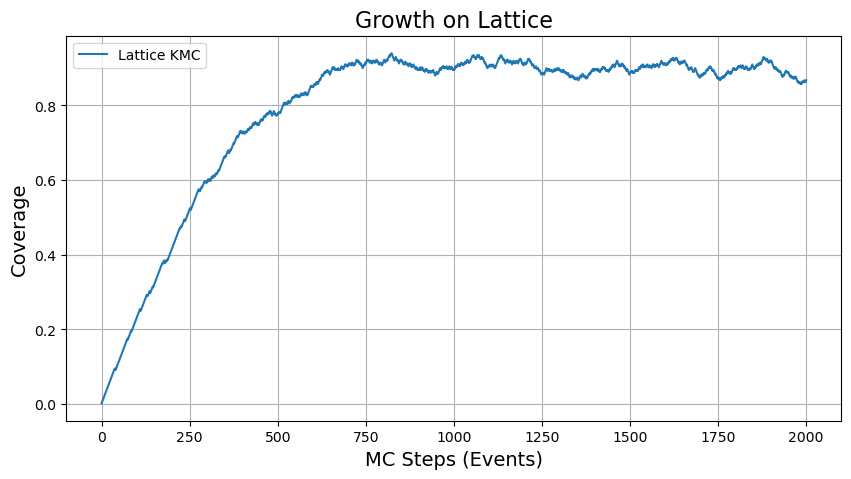

<Popen: returncode: None args: ['/Users/ap/miniforge3/envs/atomic/bin/python...>

In [12]:
# 4. Plot Coverage
plt.figure(figsize=(10,5))
plt.plot(kmc.surface_coverage, label="Lattice KMC")
plt.xlabel("MC Steps (Events)", fontsize=14)
plt.ylabel("Coverage", fontsize=14)
plt.title("Growth on Lattice", fontsize=16)
plt.grid(True)
plt.legend()
plt.show()

# 5. View Movie (Drag the slider to see atoms appearing/disappearing)
kmc.view_movie()

#### Tasks

- See how different rates change the results
- Make the rates depend on the number of neighbors
- 


In [17]:
kmc.view_movie()